In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
def update_step(c, N, k, r, dt):
    """
    Advances the master equation by one time step dt.
    c: current concentration array
    N: left boundary reservoir concentration
    k: hopping rate
    r: consumption rate at the right boundary
    """
    c_new = np.copy(c)
    
    # 1. Interior (symmetric random walk)
    for i in range(1, len(c) - 1):
        hop_in_left = k * c[i-1]
        hop_in_right = k * c[i+1]
        hop_out = 2 * k * c[i]
        c_new[i] = c[i] + dt * (hop_in_left + hop_in_right - hop_out)
        
    # 2. Right boundary (no hopping right, plus consumption)
    hop_in_left_sink = k * c[-2]
    hop_out_sink = k * c[-1]
    consumed = r * c[-1]
    c_new[-1] = c[-1] + dt * (hop_in_left_sink - hop_out_sink - consumed)
    
    # 3. Left boundary (held constant)
    c_new[0] = N
    
    return c_new

def run_simulation(N, M=20, k=50.0, r=25.0, dt=0.001, tol=1e-6):
    """
    Runs the simulation from an empty domain until steady state.
    M: number of spatial bins
    tol: tolerance for determining steady state
    """
    # Initialize
    c = np.zeros(M + 1)
    c[0] = N
    
    time_elapsed = 0.0
    
    # Define specific times to capture the transient wave
    snapshot_times = [0.01, 0.1, 0.5, 1.0]
    snapshots = []
    
    while True:
        c_new = update_step(c, N, k, r, dt)
        time_elapsed += dt
        
        # Capture transient snapshots
        if snapshot_times and time_elapsed >= snapshot_times[0]:
            snapshots.append((time_elapsed, np.copy(c_new)))
            snapshot_times.pop(0)
        
        # Check if the system has reached steady state
        max_change = np.max(np.abs(c_new - c))
        if max_change < tol:
            break
            
        c = c_new
        
    return snapshots, c_new

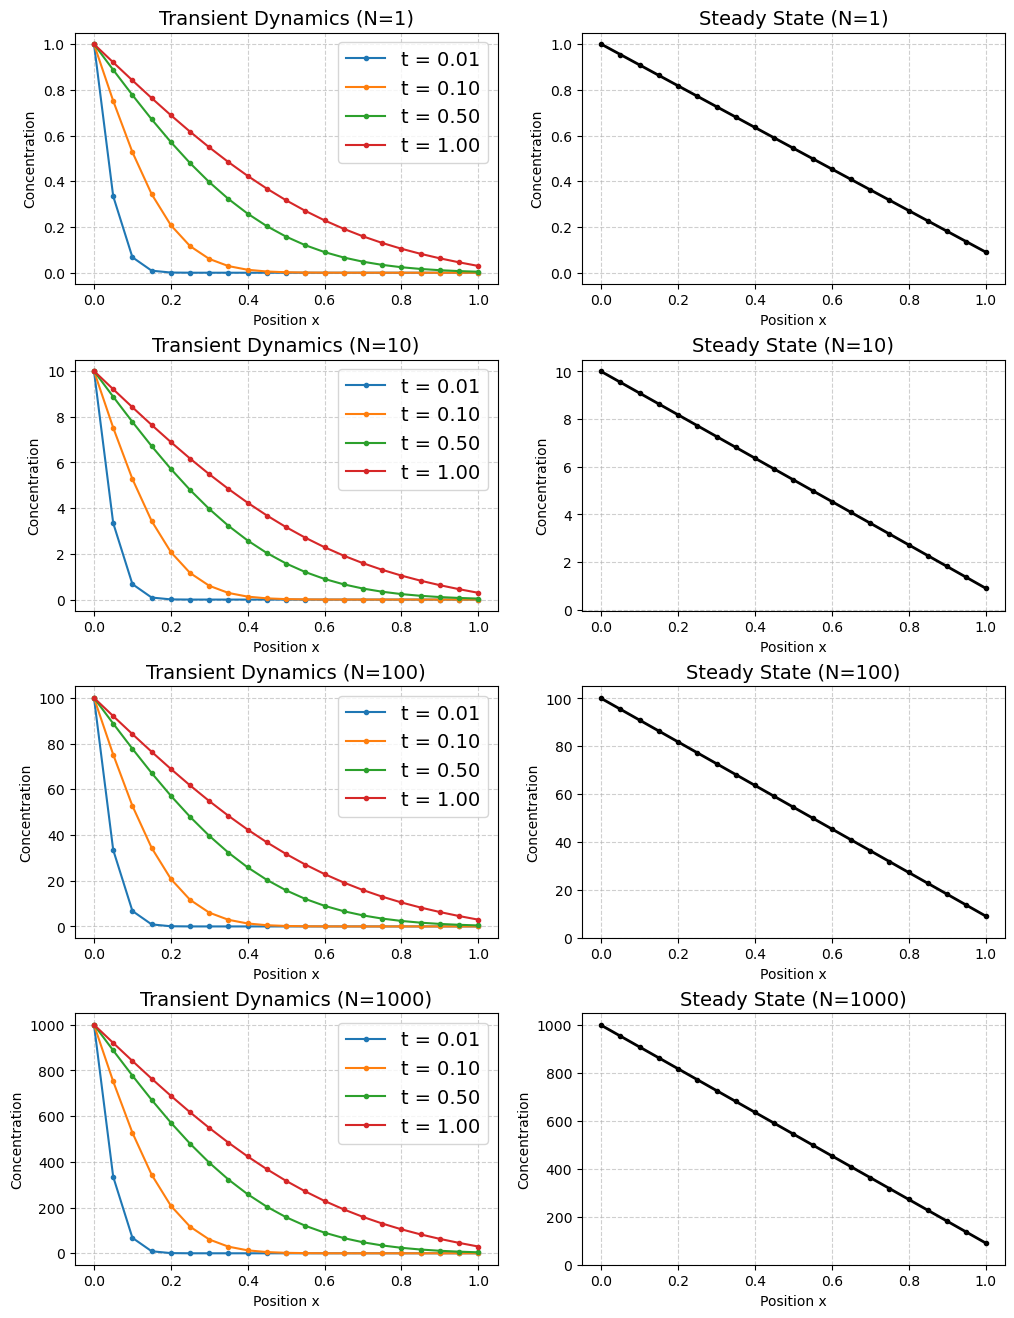

In [3]:
# Plotting

N_values = [1, 10, 100, 1000]
M = 20
x_domain = np.linspace(0, 1, M + 1)

fig, axes = plt.subplots(len(N_values), 2, figsize=(12, 4 * len(N_values)))
fig.subplots_adjust(hspace=0.3)

for i, N in enumerate(N_values):
    snapshots, c_steady = run_simulation(N, M=M)
    
    # Left Column: Transient Dynamics
    ax_trans = axes[i, 0]
    for time, snap in snapshots:
        ax_trans.plot(x_domain, snap, marker='.', label=f't = {time:.2f}')
    ax_trans.set_title(f'Transient Dynamics (N={N})', fontsize=14)
    ax_trans.set_xlabel('Position x')
    ax_trans.set_ylabel('Concentration')
    ax_trans.legend(fontsize=14)
    ax_trans.grid(True, linestyle='--', alpha=0.6)
    
    # Right Column: Steady State
    ax_steady = axes[i, 1]
    ax_steady.plot(x_domain, c_steady, color='black', linewidth=2, marker='.')
    ax_steady.set_title(f'Steady State (N={N})', fontsize=14)
    ax_steady.set_xlabel('Position x')
    ax_steady.set_ylabel('Concentration')
    ax_steady.set_ylim(-0.05, N * 1.05)
    ax_steady.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [4]:
def update_step_dimer(c, N, k, r, gamma, dt):
    """
    Advances the nonlinear master equation by one time step dt.
    Includes gamma * c^2 bimolecular degradation.
    """
    c_new = np.copy(c)
    
    # 1. Interior points with nonlinear degradation
    for i in range(1, len(c) - 1):
        hop_in_left = k * c[i-1]
        hop_in_right = k * c[i+1]
        hop_out = 2 * k * c[i]
        degradation = gamma * (c[i]**2)
        
        c_new[i] = c[i] + dt * (hop_in_left + hop_in_right - hop_out - degradation)
        
    # 2. Right boundary
    hop_in_left_sink = k * c[-2]
    hop_out_sink = k * c[-1]
    consumed_linear = r * c[-1]
    consumed_dimer = gamma * (c[-1]**2)
    
    c_new[-1] = c[-1] + dt * (hop_in_left_sink - hop_out_sink - consumed_linear - consumed_dimer)
    
    # 3. Left boundary
    c_new[0] = N
    
    return c_new


In [5]:
def run_nonlinear_steady_state(N, M=20, k=50.0, r=25.0, gamma=0.5, dt=0.001, tol=1e-6):
    """Runs the dimer simulation until steady state to compare against the linear version."""
    c = np.zeros(M + 1)
    c[0] = N
    
    while True:
        c_new = update_step_dimer(c, N, k, r, gamma, dt)
        if np.max(np.abs(c_new - c)) < tol:
            break
        c = c_new
        
    return c_new

In [6]:
def run_nonlinear_simulation(N, M=20, k=50.0, r=25.0, gamma=0.5, dt=0.001, tol=1e-6):
    """
    Runs the dimer simulation and captures transient snapshots at specific early times.
    """
    c = np.zeros(M + 1)
    c[0] = N
    
    time_elapsed = 0.0
    # Capture 2 early time points for transient dynamics comparison
    snapshot_times = [0.1, 0.5]
    snapshots = []
    
    while True:
        c_new = update_step_dimer(c, N, k, r, gamma, dt)
        time_elapsed += dt
        
        if snapshot_times and time_elapsed >= snapshot_times[0]:
            snapshots.append((time_elapsed, np.copy(c_new)))
            snapshot_times.pop(0)
            
        if np.max(np.abs(c_new - c)) < tol:
            break
        c = c_new
        
    return snapshots, c_new

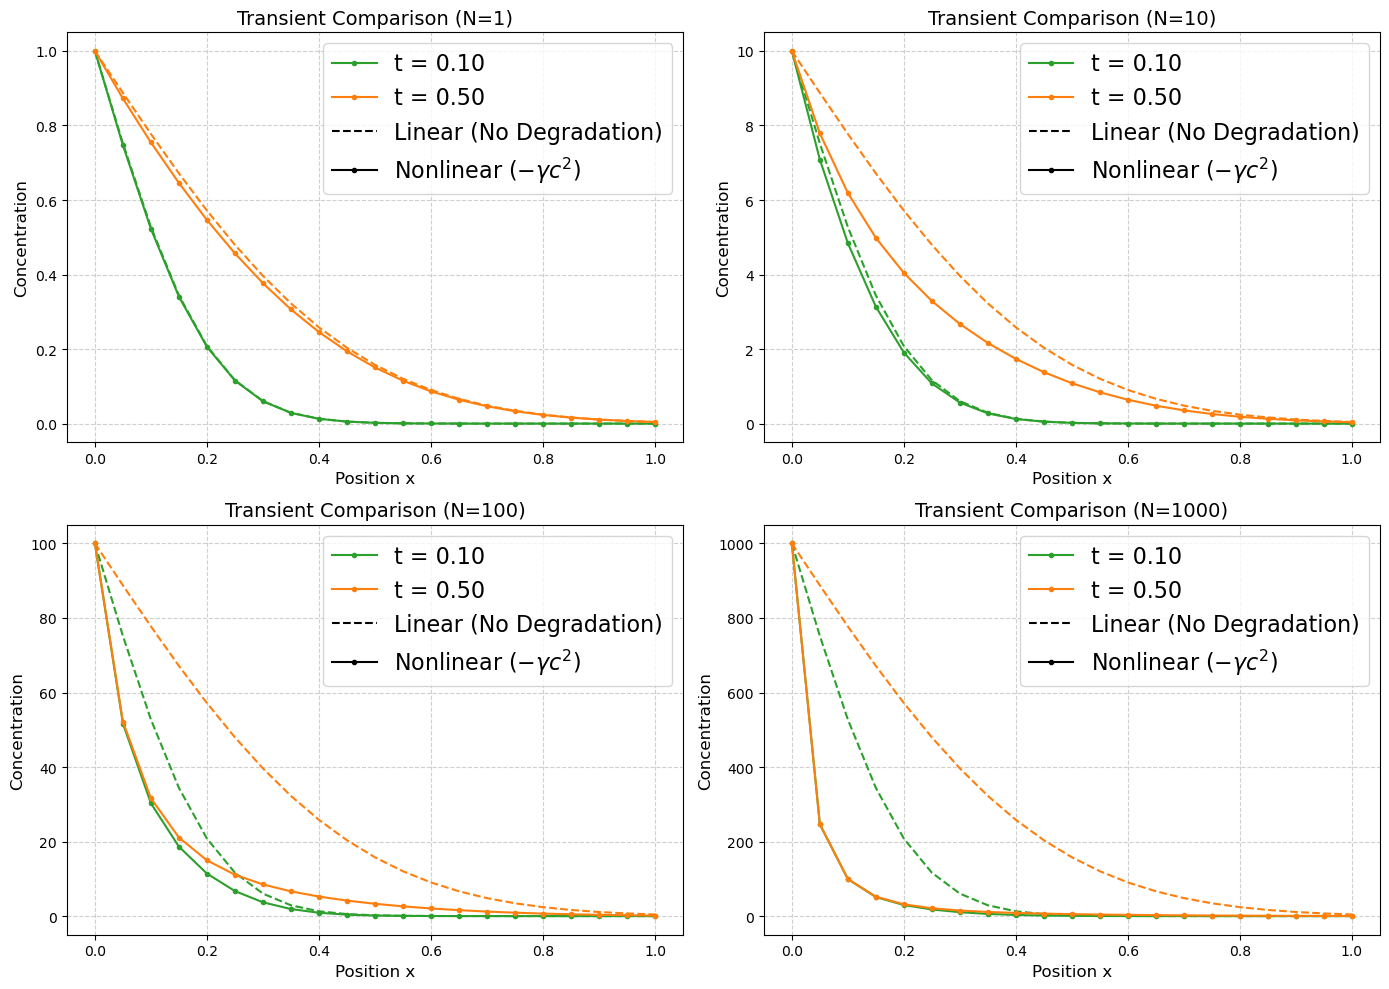

In [7]:
# Transient Plotting

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_domain = np.linspace(0, 1, M + 1)
N_values = [1, 10, 100, 1000]

# Make inear and nonlinear lines match at a given time
colors = ['tab:green', 'tab:orange']

for idx, N in enumerate(N_values):
    # Map index to 2x2 grid coordinates
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    lin_snapshots, _ = run_simulation(N, M=M)
    nonlin_snapshots, _ = run_nonlinear_simulation(N, M=M, gamma=0.5)
    
    for j in range(2):
        t_lin, c_lin = lin_snapshots[j+1]
        t_nonlin, c_nonlin = nonlin_snapshots[j]
        
        # Plot linear as dashed, nonlinear as solid with markers
        ax.plot(x_domain, c_lin, linestyle='--', color=colors[j])
        ax.plot(x_domain, c_nonlin, linestyle='-', marker='.', color=colors[j], 
                label=f't = {t_nonlin:.2f}')
    
    handles, labels = ax.get_legend_handles_labels()
    style_legend = [
        Line2D([0], [0], color='black', linestyle='--', label='Linear (No Degradation)'),
        Line2D([0], [0], color='black', linestyle='-', marker='.', label='Nonlinear ($-\gamma c^2$)')
    ]
    ax.legend(handles=handles + style_legend, loc='upper right', fontsize=16)
    
    ax.set_title(f'Transient Comparison (N={N})', fontsize=14)
    ax.set_xlabel('Position x', fontsize=12)
    ax.set_ylabel('Concentration', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

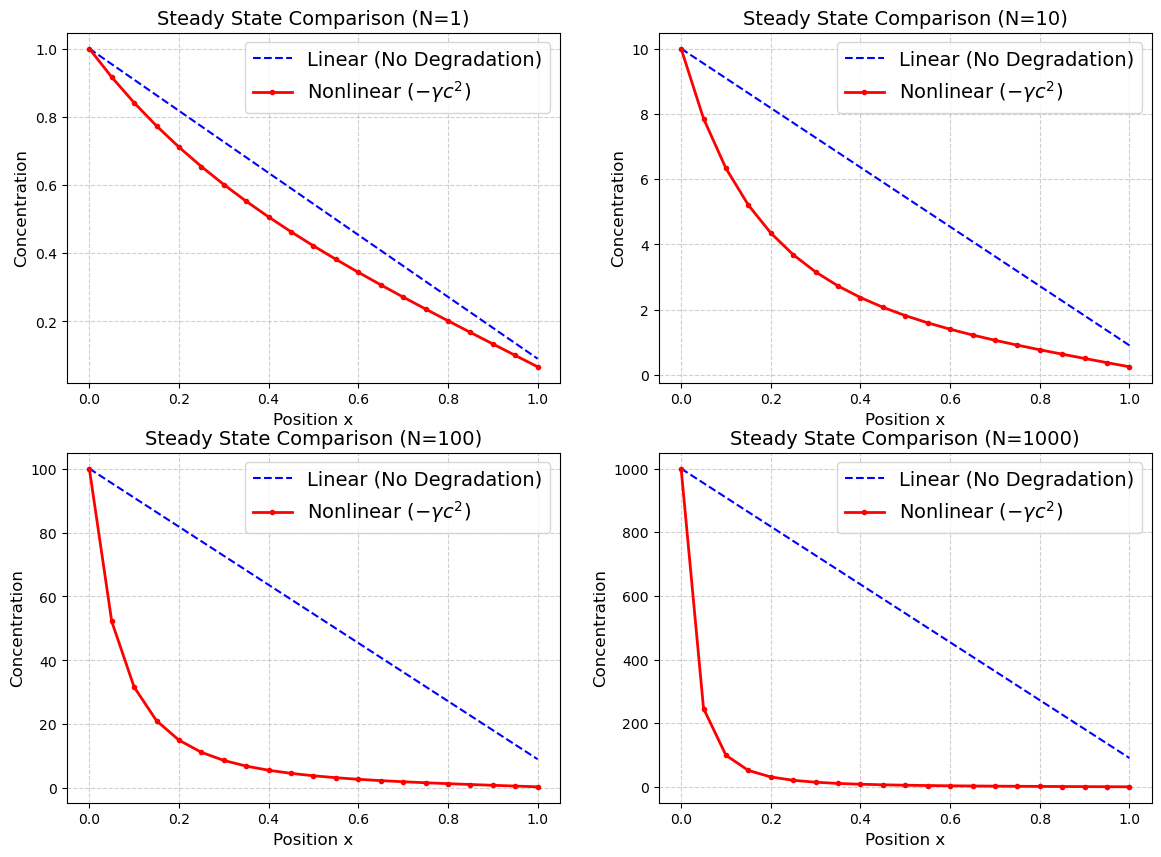

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x_domain = np.linspace(0, 1, M + 1)

# Test it for N = 1 and N = 100
for N in [1, 10, 100, 1000]:
    # Use your original function for the linear case comparison
    _, c_steady_linear = run_simulation(N, M=M) 
    c_steady_dimer = run_nonlinear_steady_state(N, M=M, gamma=0.5)
    
    ax = axes[0] if N == 1 else axes[1]
    if N == 1:
        ax = axes[0, 0]
    elif N == 10:
        ax = axes[0, 1]
    elif N == 100:
        ax = axes[1,0]
    else:
        ax = axes[1, 1]
    ax.plot(x_domain, c_steady_linear, 'b--', label='Linear (No Degradation)')
    ax.plot(x_domain, c_steady_dimer, 'r-', marker='.', linewidth=2, label='Nonlinear ($-\gamma c^2$)')
    ax.set_title(f'Steady State Comparison (N={N})', fontsize=14)
    ax.set_xlabel('Position x', fontsize=12)
    ax.set_ylabel('Concentration', fontsize=12)
    ax.legend(fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

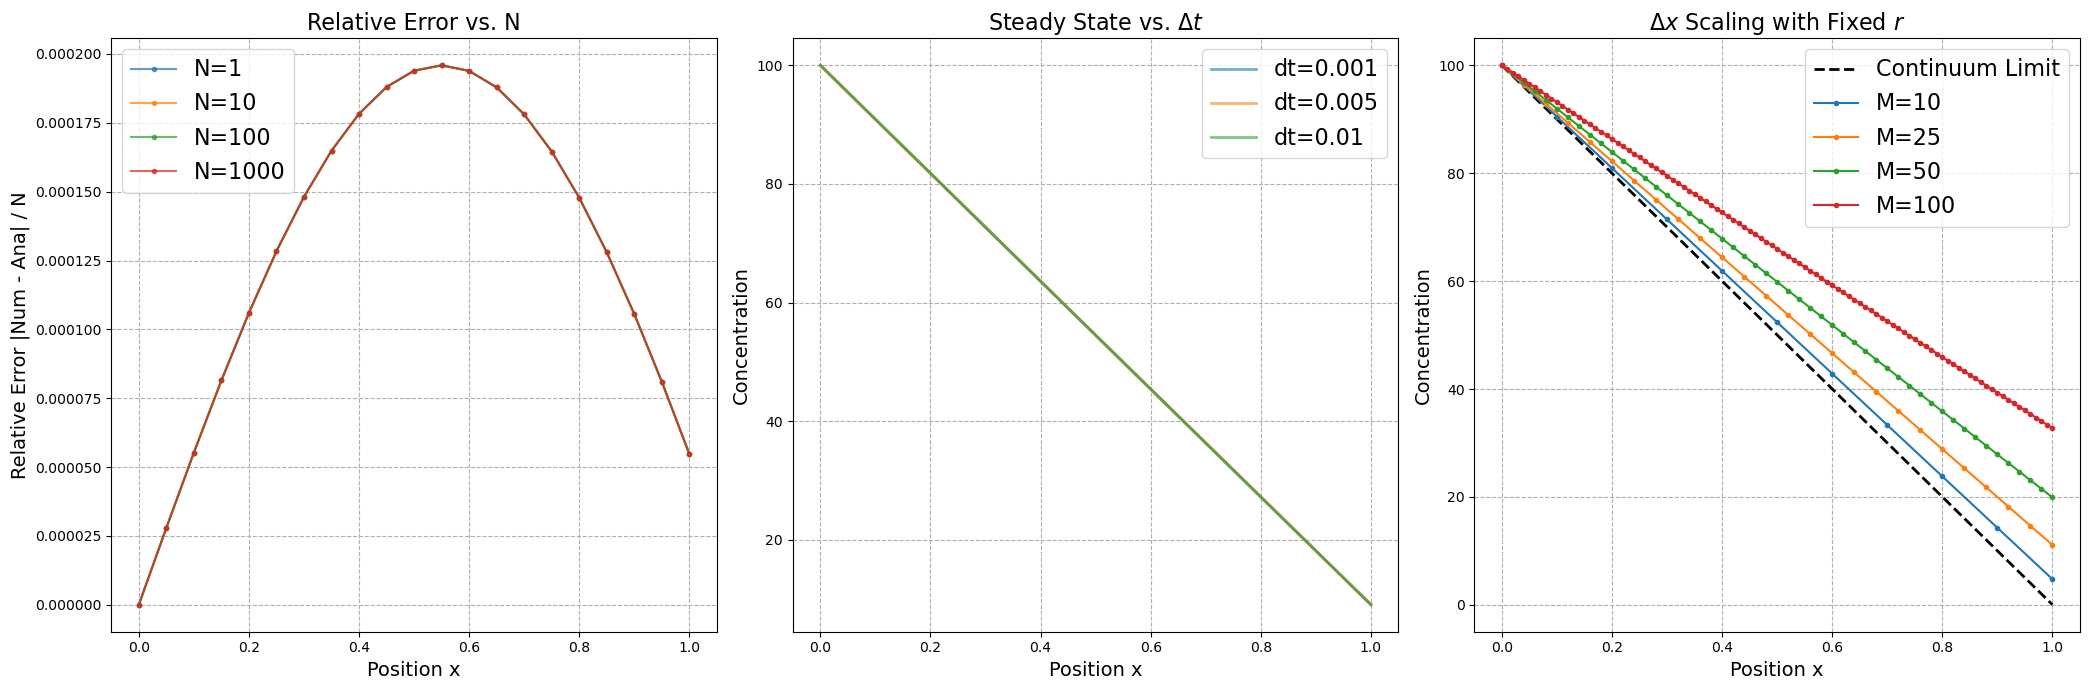

In [9]:
L = 1.0
D = 0.125       
r_base = 25.0   

def get_steady_state(N, M, D, r, dt):
    dx = L / M
    k = D / (dx**2)
    c = np.zeros(M + 1)
    c[0] = N
    tol = 1e-6
    
    while True:
        c_new = np.copy(c)
        for i in range(1, M):
            c_new[i] = c[i] + dt * k * (c[i-1] + c[i+1] - 2*c[i])
        c_new[M] = c[M] + dt * (k * c[M-1] - k * c[M] - r * c[M])
        c_new[0] = N
        
        if np.max(np.abs(c_new - c)) < tol * N:
            break
        c = c_new
    return c

def get_analytical(N, M, D, r):
    dx = L / M
    k = D / (dx**2)
    beta = r / (k * dx)
    x = np.linspace(0, L, M + 1)
    return N * (1 - (beta / (1 + beta)) * x)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# 1. N Scaling
ax = axes[0]
M = 20
dx = L / M
k = D / (dx**2)
dt = 0.5 * 1.0 / (2 * k) # Ensure Von Neumann Condition

for N in [1, 10, 100, 1000]:
    c_num = get_steady_state(N, M, D, r_base, dt)
    c_ana = get_analytical(N, M, D, r_base)
    rel_error = np.abs(c_num - c_ana) / N
    ax.plot(np.linspace(0, L, M + 1), rel_error, marker='.', label=f'N={N}', alpha=0.7)

ax.set_title('Relative Error vs. N', fontsize=16)
ax.set_xlabel('Position x', fontsize=14)
ax.set_ylabel('Relative Error |Num - Ana| / N', fontsize=14)
ax.legend(fontsize=16)
ax.grid(True, linestyle='--')

# 2. dt Independence
ax = axes[1]
N = 100
dt_values = [0.001, 0.005, 0.01] 

for dt_test in dt_values:
    c_num = get_steady_state(N, M, D, r_base, dt_test)
    ax.plot(np.linspace(0, L, M + 1), c_num, label=f'dt={dt_test}', alpha=0.6, linewidth=2)

ax.set_title('Steady State vs. $\Delta t$', fontsize=16)
ax.set_xlabel('Position x', fontsize=14)
ax.set_ylabel('Concentration', fontsize=14)
ax.legend(fontsize=16)
ax.grid(True, linestyle='--')

# 3. dx Scaling
ax = axes[2]
M_test_values = [10, 25, 50, 100]
r_true_continuum = r_base / (1.0 / 20) 
x_fine = np.linspace(0, L, 200)
c_true_limit = N * (1 - (r_true_continuum / (D + r_true_continuum)) * x_fine)

ax.plot(x_fine, c_true_limit, 'k--', linewidth=2, label='Continuum Limit')

for M_test in M_test_values:
    dx_test = L / M_test
    k_test = D / (dx_test**2)
    dt_test = 0.5 * (1.0 / (2 * k_test))
    c_unscaled = get_steady_state(N, M_test, D, r_base, dt_test)
    x_nodes = np.linspace(0, L, M_test + 1)
    ax.plot(x_nodes, c_unscaled, marker='.', label=f'M={M_test}')

ax.set_title('$\Delta x$ Scaling with Fixed $r$', fontsize=16)
ax.set_xlabel('Position x', fontsize=14)
ax.set_ylabel('Concentration', fontsize=14)
ax.legend(fontsize=16)
ax.grid(True, linestyle='--')

plt.tight_layout()
plt.show()